# Session 3 — Supervised Learning: Regression, Classification, and Not Fooling Yourself

**Practical AI & Machine Learning for Materials Science · ACerS short course**

In this notebook you will:
1. Build a complete `scikit-learn` regression workflow: split → baseline → models → metrics → parity plot.
2. Compare linear, random forest and gradient boosting models.
3. *See* overfitting, and use validation curves and cross-validation to control it.
4. Build a classifier (metal vs. non-metal) and pick the right metrics.
5. Measure how much **data leakage** inflates performance.

> **Key lesson:** how you validate matters more than the accuracy number (avoid fooling yourself).

**Optional pre-watch:** supervised learning, "linear vs non-linear models", "metrics" and "splitting into test/train/validation" lectures on the
[course YouTube playlist](https://youtube.com/playlist?list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0).

## 0. Setup

In [1]:
# --- Setup: works locally and in Google Colab ---------------------------------
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sp8rks/ACerS_AI_ML_Workshop"
if "google.colab" in sys.modules:
    ROOT = Path("/content/ACerS_AI_ML_Workshop")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve()
    while not (ROOT / "workshop_utils").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Workshop root:", ROOT)

Workshop root: C:\ACERS_AI_ML


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                             accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

from workshop_utils import load_dataset, generate_features, parity_plot

plt.rcParams["figure.dpi"] = 110
RNG = 42

## Part A — Regression: predicting bulk modulus

### A1. Featurize and split *once*, up front

We hold out a **test set** and don't touch it until the very end. All model choices are made with the training set (using cross-validation) or a separate validation set.

In [3]:
df = load_dataset("bulk_modulus")
X, y, formulae, _ = generate_features(df, elem_prop="oliynyk")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RNG)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RNG)
print(f"train {len(X_tr)} | validation {len(X_val)} | test {len(X_test)}")

Featurized 4873 formulas into 264 'oliynyk' features (skipped 32)
train 3118 | validation 780 | test 975


### A2. Always start with a baseline
If your model can't beat "predict the training mean", nothing else matters.

In [4]:
def evaluate(model, name):
    model.fit(X_tr, y_tr)
    p_tr, p_val = model.predict(X_tr), model.predict(X_val)
    return {"model": name,
            "train MAE": mean_absolute_error(y_tr, p_tr),
            "val MAE": mean_absolute_error(y_val, p_val),
            "val RMSE": root_mean_squared_error(y_val, p_val),
            "val R²": r2_score(y_val, p_val)}

models = {
    "Dummy (mean)": DummyRegressor(),
    "Ridge (linear)": make_pipeline(StandardScaler(), Ridge(alpha=10)),
    "Random forest": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG),
    "Gradient boosting": HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=RNG),
}
scores = pd.DataFrame([evaluate(m, n) for n, m in models.items()]).set_index("model")
scores.round(2)

,train MAE,val MAE,val RMSE,val R²
model,,,,
Dummy (mean),53.93,55.01,69.98,-0.00
Ridge (linear),15.81,17.07,25.07,0.87
Random forest,4.64,13.30,21.92,0.90
Gradient boosting,2.26,11.91,20.81,0.91


**Read the table carefully:**
- *Train* MAE vs. *validation* MAE: a big gap is the signature of **overfitting**. Both tree ensembles nearly memorize the training set. They still generalize best here, which is why train error alone tells you little.
- MAE is in GPa, so it is easy to interpret. RMSE punishes large errors more. R² depends on how spread out the data is (beware comparing R² across datasets).

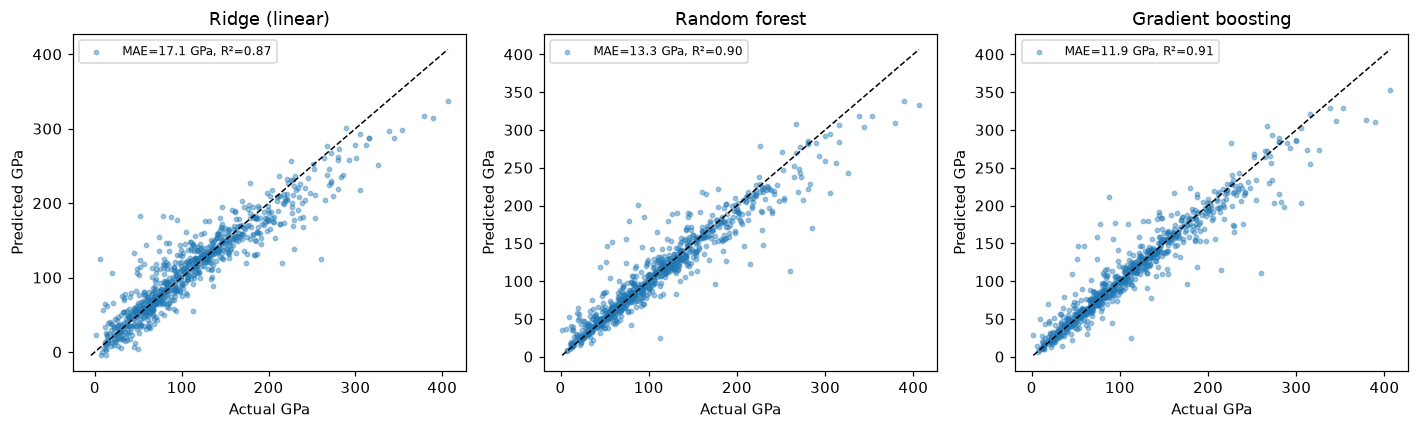

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, ["Ridge (linear)", "Random forest", "Gradient boosting"]):
    parity_plot(y_val, models[name].predict(X_val), units="GPa", ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### A3. Seeing overfitting: a validation curve

Let's vary one knob, the maximum tree depth, and watch train vs. validation error.

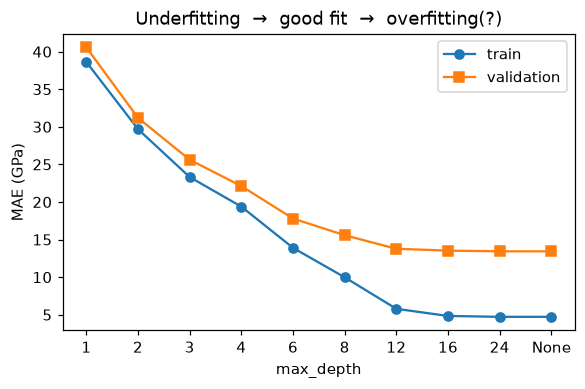

In [6]:
depths = [1, 2, 3, 4, 6, 8, 12, 16, 24, None]
curve = []
for d in depths:
    rf = RandomForestRegressor(n_estimators=150, max_depth=d, n_jobs=-1, random_state=RNG).fit(X_tr, y_tr)
    curve.append((mean_absolute_error(y_tr, rf.predict(X_tr)), mean_absolute_error(y_val, rf.predict(X_val))))
curve = np.array(curve)

labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(labels, curve[:, 0], "o-", label="train")
ax.plot(labels, curve[:, 1], "s-", label="validation")
ax.set_xlabel("max_depth"); ax.set_ylabel("MAE (GPa)")
ax.set_title("Underfitting  →  good fit  →  overfitting(?)")
ax.legend()
plt.show()

Random forests are fairly robust to overfitting because averaging many trees helps. The validation error flattens rather than rising sharply. A single deep decision tree, or a high-degree polynomial, would show the classic U-shape. ✏️ *Try it:* replace the forest with `sklearn.tree.DecisionTreeRegressor`.

### A4. Cross-validation: one split is one anecdote

A single validation split can be lucky or unlucky. K-fold CV gives a mean **and** a spread.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RNG)
for name in ["Ridge (linear)", "Random forest", "Gradient boosting"]:
    mae = -cross_val_score(models[name], X_train, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    print(f"{name:18s} CV MAE = {mae.mean():5.1f} ± {mae.std():.1f} GPa   folds: {np.round(mae, 1)}")

Ridge (linear)     CV MAE =  16.8 ± 0.7 GPa   folds: [17.1 17.9 16.3 16.8 16.1]


Random forest      CV MAE =  12.7 ± 0.7 GPa   folds: [13.4 13.6 12.2 12.3 12. ]


Gradient boosting  CV MAE =  11.3 ± 0.7 GPa   folds: [11.9 12.3 10.7 10.6 11.1]


### A5. Only now: the test set
Pick the model using CV, refit on all training data, and evaluate **once** on the test set.

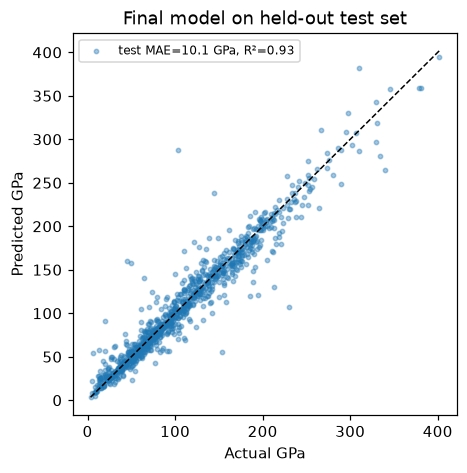

In [8]:
final = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=RNG).fit(X_train, y_train)
ax = parity_plot(y_test, final.predict(X_test), label="test", units="GPa")
ax.set_title("Final model on held-out test set")
plt.show()

## Part B — Classification: metal or non-metal?

The band-gap dataset has many entries with $E_g = 0$ (metals). A natural first task is **classification**: is $E_g > 0$?

In [9]:
bg = load_dataset("bandgap")
Xb, yb, fb, _ = generate_features(bg, elem_prop="oliynyk")
yb_cls = (yb > 0).astype(int)
print("Fraction non-metal (Eg > 0):", yb_cls.mean().round(3))

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb_cls, test_size=0.2, random_state=RNG, stratify=yb_cls)

Featurized 27600 formulas into 264 'oliynyk' features (skipped 167)
Fraction non-metal (Eg > 0): 0.509


In [10]:
clfs = {
    "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Gradient boosting": HistGradientBoostingClassifier(max_iter=300, random_state=RNG),
}
rows = []
for name, clf in clfs.items():
    clf.fit(Xb_tr, yb_tr)
    pred = clf.predict(Xb_te)
    prob = clf.predict_proba(Xb_te)[:, 1]
    rows.append({"model": name, "accuracy": accuracy_score(yb_te, pred),
                 "balanced acc.": balanced_accuracy_score(yb_te, pred),
                 "F1 (non-metal)": f1_score(yb_te, pred, zero_division=0),
                 "ROC AUC": roc_auc_score(yb_te, prob)})
pd.DataFrame(rows).set_index("model").round(3)

,accuracy,balanced acc.,F1 (non-metal),ROC AUC
model,,,,
Dummy (majority),0.509,0.500,0.675,0.500
Logistic regression,0.903,0.902,0.908,0.959
Gradient boosting,0.926,0.926,0.930,0.975


**Why so many metrics?** Here the classes happen to be nearly balanced (~51% non-metals), so accuracy is reasonable. Many materials problems are *not* balanced: stable compounds, superconductors and glass formers are rare. If only 2% of candidates are positive, a model that always says "no" scores 98% accuracy and is useless. Balanced accuracy, F1 and ROC AUC expose that. The dummy row shows what "no skill" looks like on each metric.

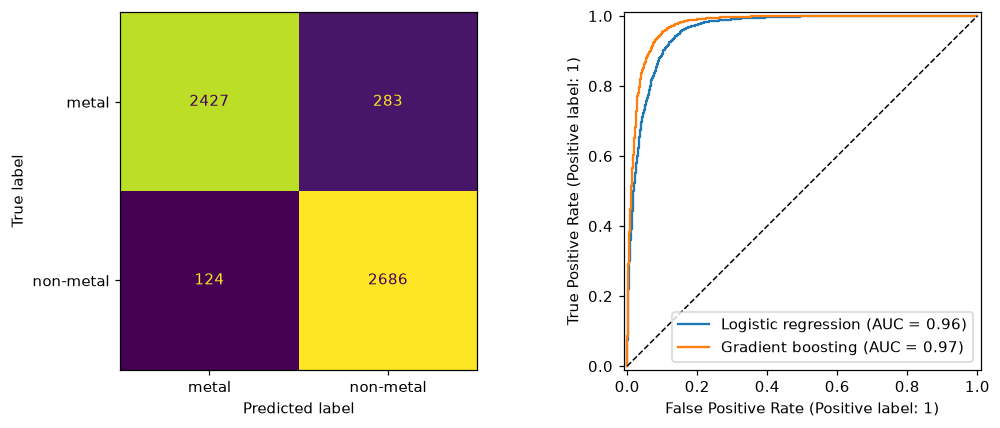

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(clfs["Gradient boosting"], Xb_te, yb_te,
                                      display_labels=["metal", "non-metal"], ax=axes[0], colorbar=False)
for name in ["Logistic regression", "Gradient boosting"]:
    RocCurveDisplay.from_estimator(clfs[name], Xb_te, yb_te, ax=axes[1], name=name)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
plt.tight_layout()
plt.show()

## Part C — Validation > accuracy: a leakage experiment

Recall the heat-capacity data from Session 1: each formula appears at many temperatures. We'll predict $C_p$ from composition + temperature, validating two ways:
- **Random K-fold:** rows from the same compound land in both train and test.
- **Group K-fold:** all temperatures of a compound stay together, so the test compounds are truly *new*.

In [12]:
cp = load_dataset("heat_capacity_clean")
Xc, _, fc, _ = generate_features(cp.rename(columns={"Cp": "target"}), elem_prop="oliynyk",
                                 drop_duplicates=False, verbose=False)
Xc = Xc.filter(like="avg_")
Xc["T"] = cp["T"].values
yc = cp["Cp"].values
groups = fc.values

model = RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=RNG)
mae_random = -cross_val_score(model, Xc, yc, cv=KFold(5, shuffle=True, random_state=RNG),
                              scoring="neg_mean_absolute_error")
mae_group = -cross_val_score(model, Xc, yc, cv=GroupKFold(5), groups=groups,
                             scoring="neg_mean_absolute_error")
print(f"Random K-fold MAE: {mae_random.mean():5.1f} J/mol·K   ← looks great…")
print(f"Group  K-fold MAE: {mae_group.mean():5.1f} J/mol·K   ← what you'd actually get on a new compound")

Random K-fold MAE:   2.6 J/mol·K   ← looks great…
Group  K-fold MAE:  29.7 J/mol·K   ← what you'd actually get on a new compound


Same model, same data, very different conclusion. **Always ask: does my test set look like the cases I'll really predict?**
Common leakage sources in materials data:
- the same compound at multiple conditions (T, P, doping level)
- near-duplicate compositions (e.g. Ba₀.₄₉Sr₀.₅₁TiO₃ vs Ba₀.₅Sr₀.₅TiO₃)
- the same sample measured repeatedly or by multiple labs
- feature scaling or selection done *before* the split
- choosing hyperparameters by looking at the test set

## Hands-on exercises

1. **Predict another property.** Swap in `"shear_modulus"` or `"log10_thermal_conductivity"` in Part A. Which model wins? How do the errors compare to the spread of the data?
2. **Regression on band gap.** Using *only* non-metals (`yb > 0`), train a regressor for $E_g$. Then combine it with the classifier into a two-stage model.
3. **Learning curve.** Train the gradient-boosting model on 100, 300, 1000 and 3000 compounds. Plot validation MAE vs. training size. How much more data would you need to halve the error?
4. **Hyperparameters.** Tune `learning_rate` and `max_iter` with `GridSearchCV` on the training set only.

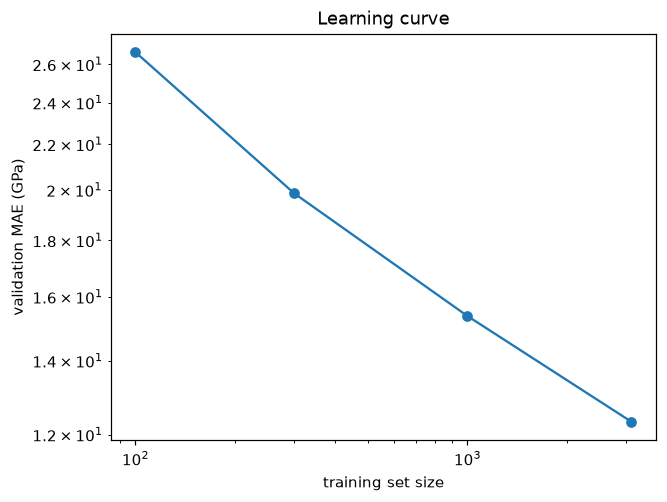

In [13]:
# Exercise 3 starter: learning curve
sizes = [100, 300, 1000, len(X_tr)]
lc = []
for n in sizes:
    m = HistGradientBoostingRegressor(max_iter=300, random_state=RNG).fit(X_tr.iloc[:n], y_tr.iloc[:n])
    lc.append(mean_absolute_error(y_val, m.predict(X_val)))
plt.loglog(sizes, lc, "o-"); plt.xlabel("training set size"); plt.ylabel("validation MAE (GPa)")
plt.title("Learning curve"); plt.show()

---
**Next session:** model interpretation, uncertainty, and when *not* to trust a model.

**Go deeper:** full course `worked_examples/best_practices` (the companion notebooks to Wang *et al.*,
["Machine Learning for Materials Scientists: An Introductory Guide toward Best Practices", *Chem. Mater.* 2020](https://doi.org/10.1021/acs.chemmater.0c01907)),
`worked_examples/cross_validation`, `worked_examples/random_forest`, `worked_examples/hyperparameter_opt`.
Free textbook: [*An Introduction to Statistical Learning*](https://www.statlearning.com/).